# Biorep1 Compound Analysis (Aroma Identification → Matched Intensity Matrix)

**What this notebook does:**  
This notebook performs **compound-level analysis** for **biorep2** (as independent batch) TD–GC–MS data. It combines compound identification tables (e.g., NIST outputs) across file types (samples/QC/blanks/environment), applies **contamination filtering** using blanks/environment/QC, and matches identified compounds to the **quantified peak table** (typically drift-corrected and normalised in the data-preparation workflow). The final output is an **analysis-ready aroma intensity matrix** (Variety × Compound) plus summary tables.

**Main steps (high level):**
- Load and combine compound identification files; label FileType (sample/QC/blank/env)
- Filter likely contaminants based on overlap with blanks/environment/QC (RT tolerance)
- Harmonise compound names (canonical mapping / alias handling when provided)
- Match compounds to quantified peaks using RT (and optional m/z) tolerances
- Build aroma outputs: long-format matched table + wide intensity matrix (Variety × Compound)
- link with sensory data
- Sensory score prediction for non-panel varieties

**Module dependency:**  
This notebook uses reusable helper functions from **`compound_analysis_module.py`** for compound parsing, contamination filtering, RT/mz matching, and aroma-matrix construction.
Biorep2 is as indepentednt batch for evaluation of model generaliazation and all the processes are like biorep1 so I did not use any explanation.

---
**Author:** Fatemeh Monfared  
**Thesis:** Data-Driven Analysis of Potato Aroma and Flavor Using TD–GC–MS and Machine Learning  
**Affiliation:** Hanze University of Applied Sciences  
**Year:** 2026


In [1]:

import glob, os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import importlib
from IPython.display import display
import compound_analysis_module 
importlib.reload(compound_analysis_module)
import  yaml
import numpy as np
import pandas as pd


 # NIST Compound Identification Integration (Samples vs Blank/Env Baseline)

In [2]:
from compound_analysis_module import combine_compound_data

# USER SETTINGS

CONFIG_PATH = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\config.yaml"
REP = "biorep2"  


with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

paths = config[REP]["data_paths"]




sample_files = paths.get("sample_files", []) or []
base_compound_dir = paths.get("base_compound_dir", "") or ""
output_path = paths.get("output_path", "") or ""

blank_files = paths.get("blank_files", []) or []
env_files = paths.get("env_files", []) or []

def norm(p: str) -> str:
    return os.path.normpath(p) if isinstance(p, str) else p

sample_files = [norm(p) for p in sample_files]
blank_files  = [norm(p) for p in blank_files]
env_files    = [norm(p) for p in env_files]
base_compound_dir = norm(base_compound_dir)
output_path = norm(output_path)

if not blank_files:
    blank_files = glob.glob(os.path.join(base_compound_dir, "day_*", "*blank*.csv"))
if not env_files:
    env_files = glob.glob(os.path.join(base_compound_dir, "day_*", "*env*.csv"))

print(f"Rep selected: {REP}")
print(f"Base compound dir: {base_compound_dir}")
print(f"Output path: {output_path}")
print(f"Samples: {len(sample_files)} | blanks: {len(blank_files)} | env: {len(env_files)}")



combined_df = combine_compound_data(
    base_dir=base_compound_dir,
    sample_files=sample_files,
    env_files=env_files,
    blank_files=blank_files,
    output_path=output_path
)

print("Done. Rows:", len(combined_df))
if "FileType" in combined_df.columns:
    print(combined_df["FileType"].value_counts())

display(combined_df.head(10))


Rep selected: biorep2
Base compound dir: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\raw_data\compounds
Output path: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\biorep2\combined.csv
Samples: 94 | blanks: 1 | env: 1

Combined file saved to: C:\Users\fatemehm\OneDrive - Royal HZPC Group\Documents\GitHub\internship\biorep2\combined.csv

FileType counts:
FileType
sample    18334
env          22
blank        12
Name: count, dtype: int64

Preview:
   Component RT                  Compound Name  Match Factor  Best Hit  \
0      1.999217                        Propene     65.242228      True   
1      2.177691        2-Propanone, 1-methoxy-     87.899550      True   
2      2.359333            Propanal, 2-methyl-     78.339167      True   
3      2.465450  l-2-Amino-4-methyl-1-pentanol     68.259874      True   
4      2.504033        Undecane, 2,2-dimethyl-     68.175810      True   

   Formula  Base Peak MZ FileType   FileName  RI 

,Component RT,Compound Name,Match Factor,Best Hit,Formula,Base Peak MZ,FileType,FileName,RI
0,1.999217,Propene,65.242228,True,C3H6,40.959613,sample,ADORA.csv,NaN
1,2.177691,"2-Propanone, 1-methoxy-",87.899550,True,C4H8O2,44.960000,sample,ADORA.csv,NaN
2,2.359333,"Propanal, 2-methyl-",78.339167,True,C4H8O,42.964126,sample,ADORA.csv,NaN
3,2.465450,l-2-Amino-4-methyl-1-pentanol,68.259874,True,C6H15NO,42.970000,sample,ADORA.csv,NaN
4,2.504033,"Undecane, 2,2-dimethyl-",68.175810,True,C13H28,56.987282,sample,ADORA.csv,NaN
5,2.623000,"1,3,5-Trifluorobenzene",83.196509,True,C6H3F3,131.918292,sample,ADORA.csv,NaN
6,2.893083,"Butanal, 3-methyl-",95.564375,True,C5H10O,43.956820,sample,ADORA.csv,NaN
7,2.979900,Benzene,75.424866,True,C6H6,77.968884,sample,ADORA.csv,NaN
8,3.201767,"1-Hexanol, 2,2-dimethyl-",71.328684,True,C8H18O,42.960000,sample,ADORA.csv,NaN
9,3.311083,Pentanal,85.989404,True,C5H10O,43.955342,sample,ADORA.csv,NaN


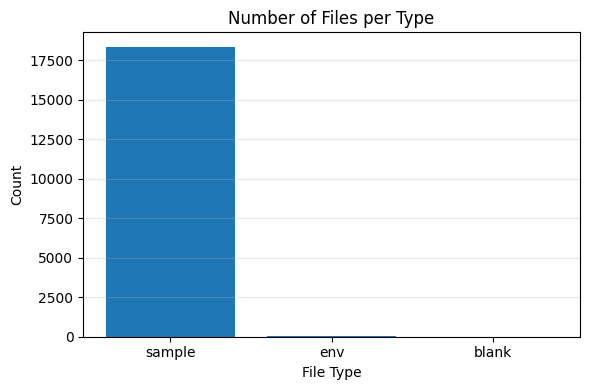

FileType
sample    18334
env          22
blank        12
Name: count, dtype: int64


In [3]:

from compound_analysis_module import plot_filetype_counts

plot_filetype_counts(combined_df)


# Contamination filtering

Sample compounds before filtering: 18334
Sample compounds after filtering: 16602
Removed 1732 sample peaks (ΔRT ≤ 0.4)


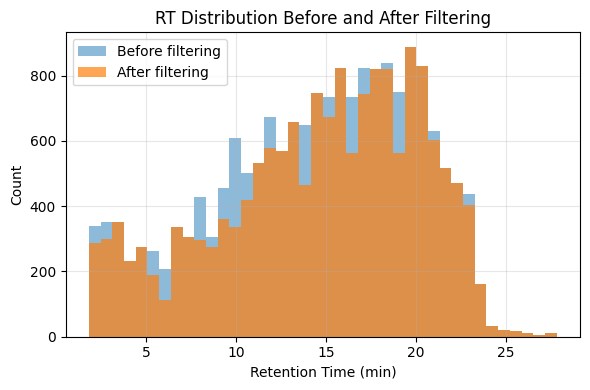

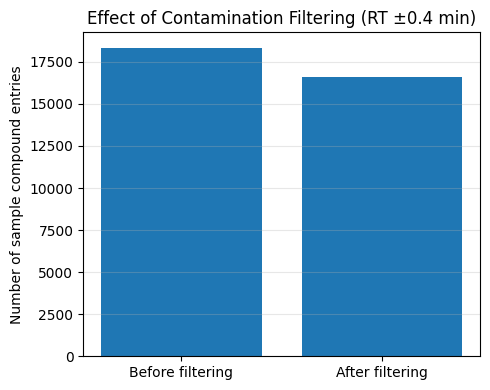

Before: 18334, After: 16602


In [4]:

from compound_analysis_module import (
    filter_real_compounds,
    plot_rt_distribution,
    plot_filtering_effect
)

# Filtering
real_compounds = filter_real_compounds(combined_df, rt_tolerance=0.4)

# Plots
plot_rt_distribution(combined_df, real_compounds)
plot_filtering_effect(combined_df, real_compounds, rt_tolerance=0.4)


# Loading the pereprocessed sample (biorep1)

In [5]:

csv_path = config["biorep2"]["data_paths"]["sample"]


# Load the data
samples_filtered = pd.read_csv(csv_path)
print(samples_filtered.head())


           Filename                          Sample  Peak   Variety  tR_best  \
0  S96_51_B2_D11_T1     NLD;MET;96;64;2024;51;HANSA     1     HANSA    1.901   
1   S96_5_B2_D11_T1    NLD;MET;96;64;2024;5;ALTURAS     1   ALTURAS    1.901   
2   S96_9_B2_D11_T1       NLD;MET;96;64;2024;9;ANTI     1      ANTI    1.901   
3  S96_80_B2_D11_T1    NLD;MET;96;64;2024;80;SABABA     1    SABABA    1.901   
4  S96_88_B2_D11_T1  NLD;MET;96;64;2024;88;SYMFONIA     1  SYMFONIA    1.901   

   m/z  Intensity_corrected  Ratio_normalized  Log10_normalized  
0   40         30493.894525          5.606763          0.819989  
1   40         25559.832869          4.699561          0.755841  
2   40         32550.448201          5.984891          0.844160  
3   40         28380.586045          5.218199          0.793665  
4   40         30155.555468          5.544554          0.815880  


# Checking the presence of known potato aroma compounds

In [6]:
from compound_analysis_module import match_potato_aromas_strict
rename_map = {
    "Component": "Component RT",
    "Compound": "Compound Name",
    "Name": "Compound Name"
}
real_compounds = real_compounds.rename(
    columns={k: v for k, v in rename_map.items() if k in combined_df.columns}
)

real_compounds["FileType"] = "sample"

print("Combined rows:", len(combined_df))
biorep2_cfg = config["biorep2"]


res = match_potato_aromas_strict(
    combined_df=real_compounds,
    samples_filtered_path=biorep2_cfg["data_paths"]["sample"],
    out_dir="C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep2",
    paths=paths,
    rt_tol=0.4,
    mz_tol=0.5
)



aroma_matrix_output = "C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep2/aroma_matrix.csv"
os.makedirs(os.path.dirname(aroma_matrix_output ), exist_ok=True)
aroma_matrix = res["aroma_matrix"].copy()

print("Aroma matrix shape:", aroma_matrix.shape)
display(aroma_matrix.head())
aroma_matrix.to_csv(aroma_matrix_output )
print("Aroma matrix saved to:", aroma_matrix_output)


Combined rows: 18368
Aroma matrix shape: (94, 62)


Compound Name,Variety,(E)-2-Heptenal,1-Heptanol,"1-Hexanol, 2-ethyl-",1-Nonanol,1-Phenylethanol,"2(3H)-Furanone, dihydro-5-pentyl-","2,3-Butanedione","2,3-Pentanedione",2-Ethylfuran,...,Pentanal,Phenol,Phenylacetaldehyde,Propanoic acid,Styrene,Tetradecane,Tridecanal,Tridecane,n-Hexadecanoic acid,n-Hexane
0,ADORA,128937.591758,437142.618582,56064.041869,38119.222323,55570.692251,4.038904e+05,2.022206e+06,325499.702136,121322.202549,...,1.981593e+06,520883.461173,559744.326155,79593.974753,1.201266e+06,420510.925086,683486.054649,79593.974753,1.916042e+06,155075.229763
1,AGRIA,55666.690119,199337.469940,30443.492081,27321.683115,16118.227538,5.362715e+05,1.566615e+06,197136.144169,125679.229531,...,1.605564e+06,360927.315717,309514.412284,69599.280448,1.097296e+06,301266.295308,458970.526914,69599.280448,1.379516e+06,137093.221158
2,ALOUETTE,49631.784002,181032.023067,27167.898438,40297.718702,44754.442945,3.517344e+05,1.346653e+06,129480.954298,51147.591764,...,6.410122e+05,524955.993054,706478.790956,61526.963538,5.315566e+05,341353.919584,463992.631061,61526.963538,1.864977e+06,28704.113485
3,ALTHEA,40471.198813,160737.184925,45157.734595,51039.401309,10701.753661,1.541189e+06,1.658467e+06,151672.789562,49914.514000,...,1.293619e+06,483936.007551,432336.625301,112011.855124,3.057428e+05,216743.117814,318054.208623,112011.855124,1.121340e+06,76881.139673
4,ALTURAS,68142.516090,152608.239950,29027.003621,32503.725809,33904.204905,3.932889e+05,1.094130e+06,159279.917005,55120.328968,...,1.092687e+06,669396.965469,538647.377488,45549.791518,4.320259e+05,279013.119126,181354.476251,45549.791518,8.241577e+05,132582.463421


Aroma matrix saved to: C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep2/aroma_matrix.csv


# Classification of Aroma Compounds by Chemical Family

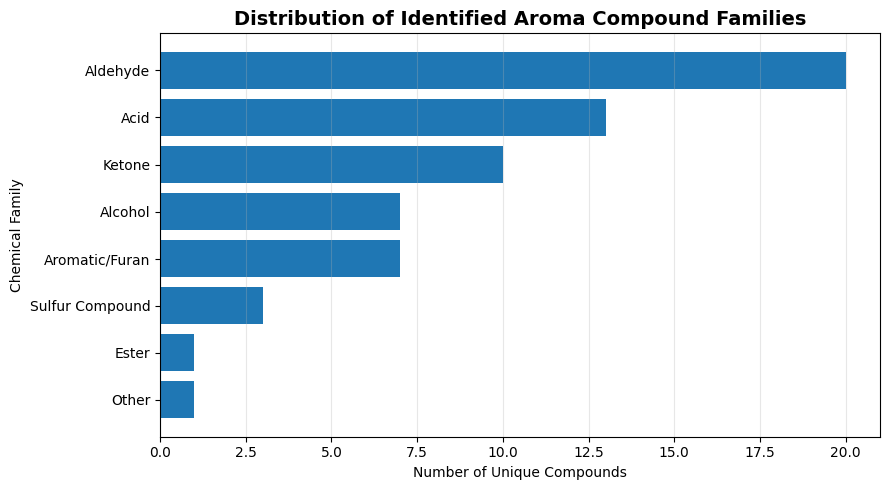

Chemical_Family
Aldehyde           20
Acid               13
Ketone             10
Alcohol             7
Aromatic/Furan      7
Sulfur Compound     3
Ester               1
Other               1
dtype: int64

In [7]:
from compound_analysis_module import (
    assign_aroma_descriptions_and_families,
    plot_aroma_family_distribution_unique
)

#  wide -> long
id_col = aroma_matrix.index.name or "Variety"

aroma_long = (
    aroma_matrix
    .reset_index()
    .melt(
        id_vars=[id_col],
        var_name="Compound Name",
        value_name="Intensity"
    )
    .rename(columns={id_col: "Variety"})
)

#  numeric cleanup
aroma_long["Intensity"] = (
    aroma_long["Intensity"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

aroma_long["Intensity"] = pd.to_numeric(aroma_long["Intensity"], errors="coerce")

#  filter
aroma_long = aroma_long.dropna(subset=["Intensity"])
aroma_long = aroma_long.loc[aroma_long["Intensity"] > 0].copy()

# annotate (IMPORTANT: unpack!)
aroma_long, aroma_desc_map, chemical_family_map = (
    assign_aroma_descriptions_and_families(aroma_long)
)

# plot
plot_aroma_family_distribution_unique(aroma_long)


#  PCA + K-Means Clustering of Potato Aroma Profiles (k = 2; 64.8% Variance in PC1–PC2)

Explained variance (2 PCs): 35.17%
Optimal k (silhouette): 3


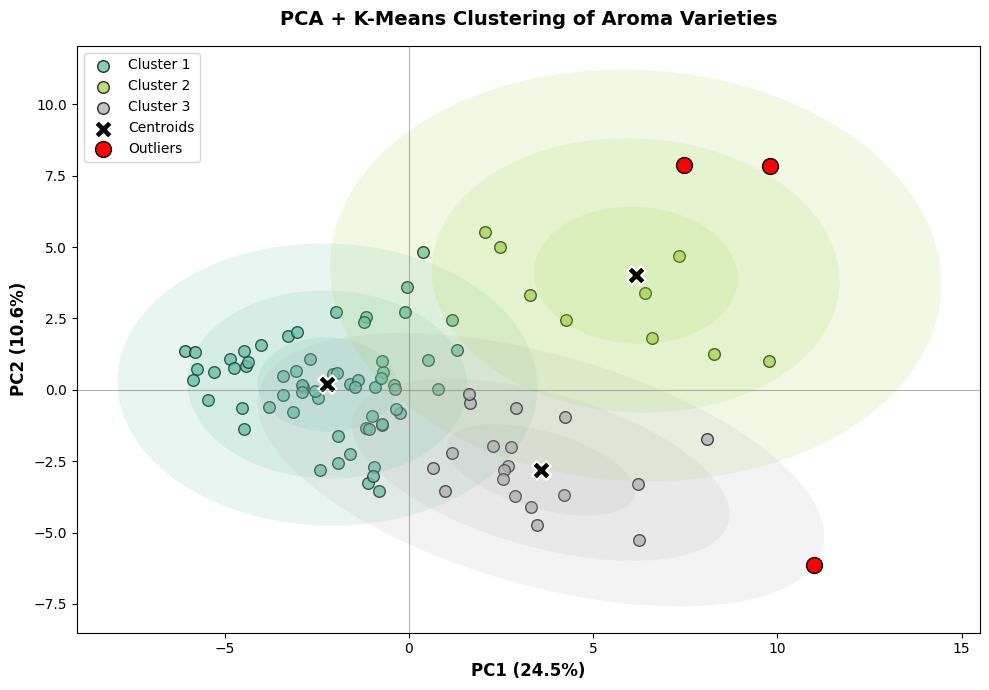

In [8]:

from compound_analysis_module import pca_kmeans_aroma


results, X_pca, clusters = pca_kmeans_aroma(aroma_matrix)

# GMM Clustering of Aroma Profiles with PCA-Based Model Selection (AIC/BIC)

PCA comps for ≥90% variance: 18 (90.4%)


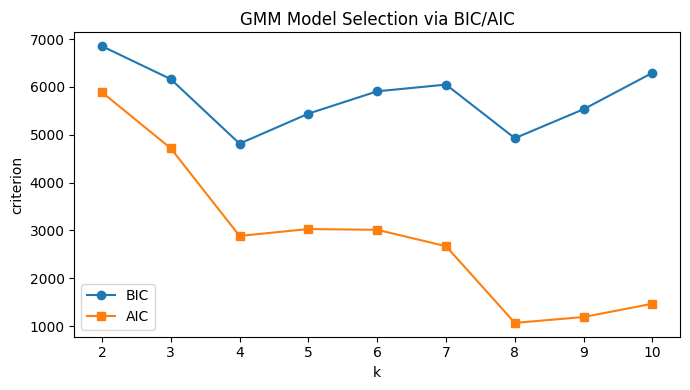

Best k by BIC: 4
Silhouette=0.218 | DBI=1.832 | CHI=13.6
Outliers detected: 3 / 94
Outlier varieties (sorted by Mahalanobis distance):
 - HANSA | Cluster=3 | Mahalanobis=3.962
 - SAGITTA | Cluster=4 | Mahalanobis=3.704
 - AVENGER | Cluster=3 | Mahalanobis=3.621


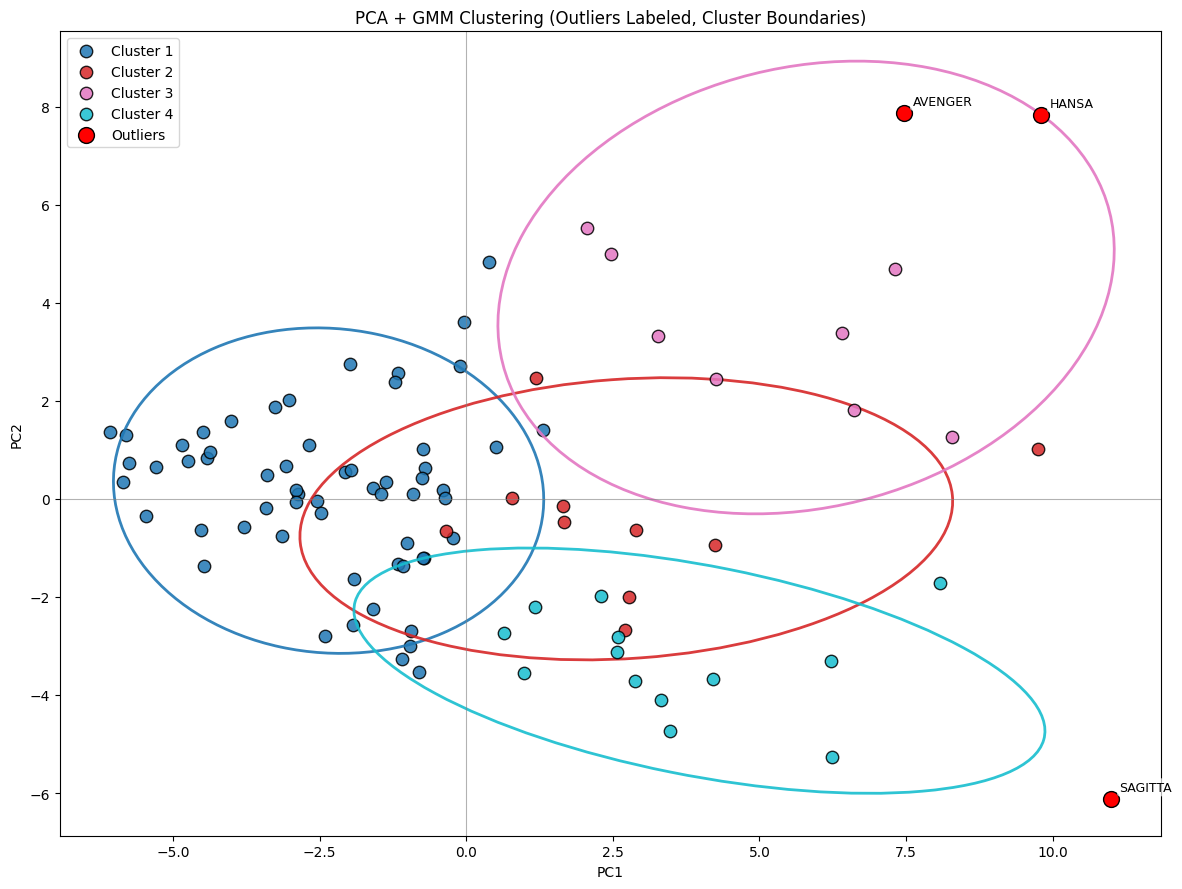

c:\Users\fatemehm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


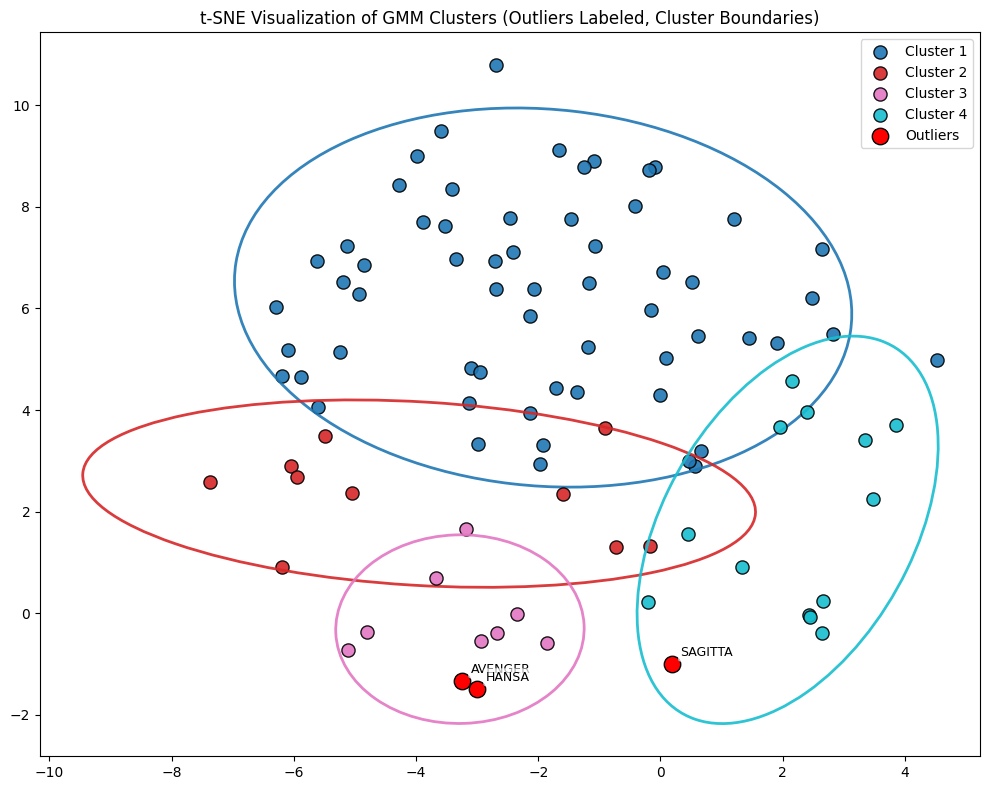

In [ ]:

from compound_analysis_module import analyze_aroma_clusters_gmm

results, cluster_means = analyze_aroma_clusters_gmm(aroma_matrix)


# Comparative Analysis of Aroma Caompound Classes Between Outlier and other Potato Varieties

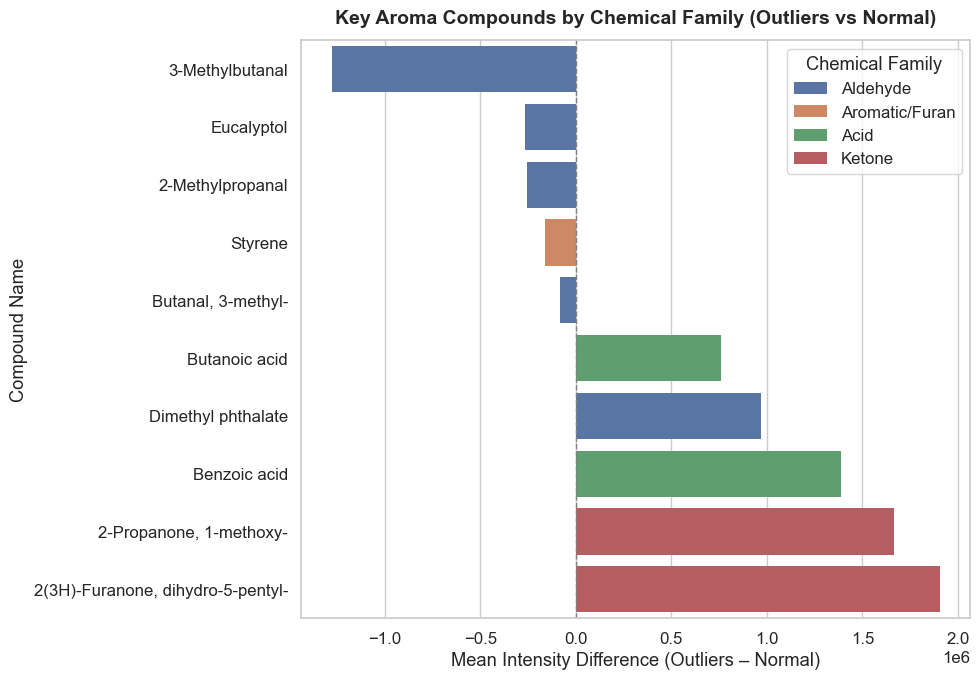

Saved plot: aroma_cluster_results\outlier_vs_normal_aromas.png


Group,Compound Name,Normal,Outlier,Difference,Chemical Family
19,3-Methylbutanal,3.490731e+06,2.213567e+06,-1.277165e+06,Aldehyde
37,Eucalyptol,3.881038e+06,3.614230e+06,-2.668082e+05,Aldehyde
11,2-Methylpropanal,5.868730e+05,3.320617e+05,-2.548113e+05,Aldehyde
55,Styrene,9.740882e+05,8.133293e+05,-1.607589e+05,Aromatic/Furan
26,"Butanal, 3-methyl-",2.056710e+05,1.242950e+05,-8.137604e+04,Aldehyde
27,Butanoic acid,3.702538e+05,1.129741e+06,7.594871e+05,Acid
31,Dimethyl phthalate,5.286158e+05,1.496666e+06,9.680503e+05,Aldehyde
23,Benzoic acid,4.315171e+05,1.817074e+06,1.385557e+06,Acid
13,"2-Propanone, 1-methoxy-",6.641308e+06,8.306800e+06,1.665492e+06,Ketone
5,"2(3H)-Furanone, dihydro-5-pentyl-",6.595641e+05,2.564913e+06,1.905349e+06,Ketone


In [10]:

from compound_analysis_module import plot_outlier_vs_normal_aromas


outliers = ['AVENGER', 'HANSA', 'SAGITTA']

top_diff = plot_outlier_vs_normal_aromas(aroma_matrix, outliers, chemical_family_map, output_dir="aroma_cluster_results")

display(top_diff)

#  Major Contributing Aroma Compounds (Mean Intensity-Based Ranking)


                                  mean         std
Compound Name                                     
2-Propanone, 1-methoxy-     6694461.86  2435517.32
Eucalyptol                  3872523.15  1369360.64
3-Methylbutanal             3449970.89  2134348.73
Dimethyl disulfide          3001883.24  1003242.84
n-Hexadecanoic acid         1776285.73   807845.75
Acetic acid, ethenyl ester  1728881.62   725309.80
Acetic acid, methyl ester   1728881.62   725309.80
2,3-Butanedione             1728881.62   725309.80
Furan, 2-pentyl-            1198905.09  1375382.30
Pentanal                    1118488.09   722736.50


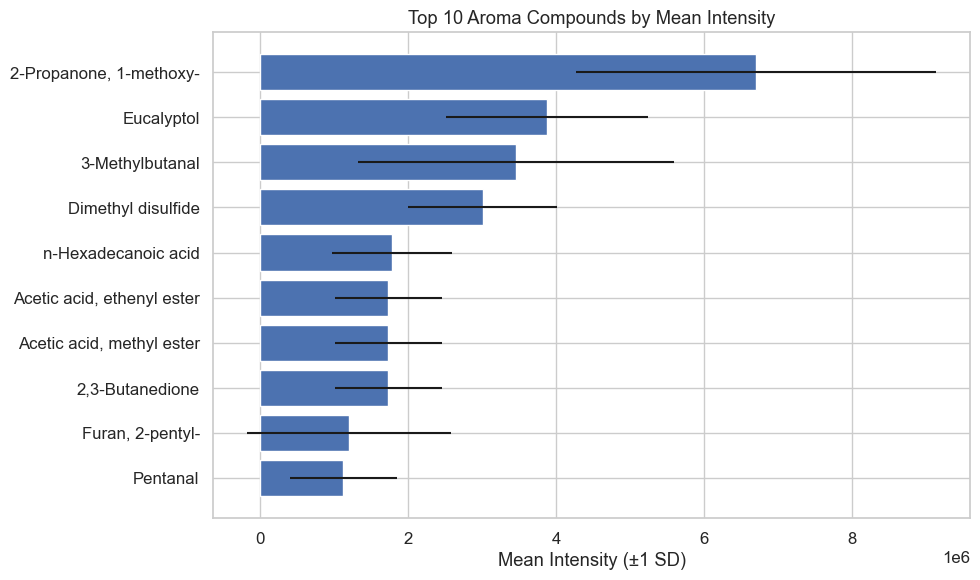

In [11]:

from compound_analysis_module import summarize_aroma_intensities

desc_stats, top_compounds = summarize_aroma_intensities(aroma_matrix, top_n=10)

# Heatmap of Top Aroma Compounds in Potato Varieties

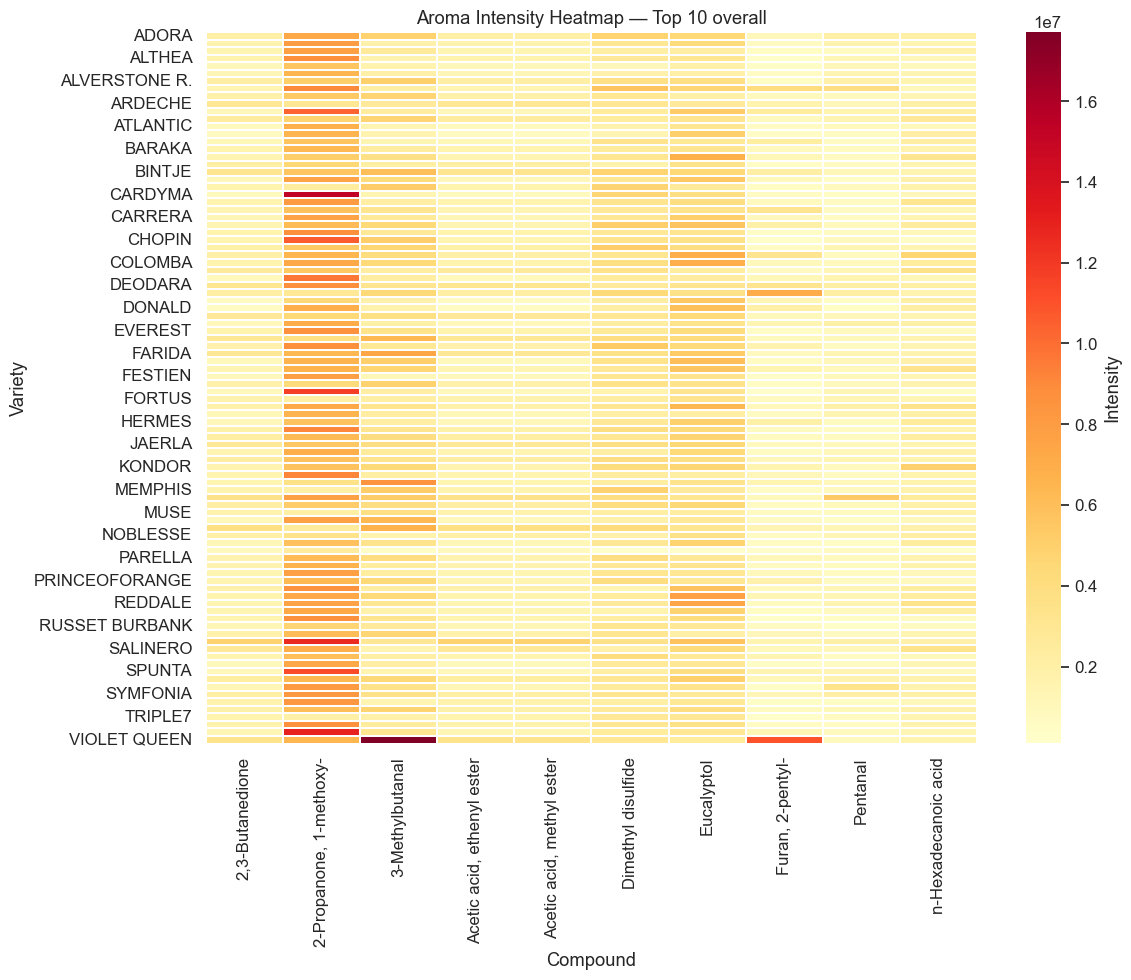

In [12]:

from compound_analysis_module import plot_top_aroma_heatmap

# Show top 10 compounds overall across varieties
plot_top_aroma_heatmap(aroma_matrix, top_n=10, mode="overall")

# Feature Importance Analysis of Aroma Compounds Using PCA Loadings

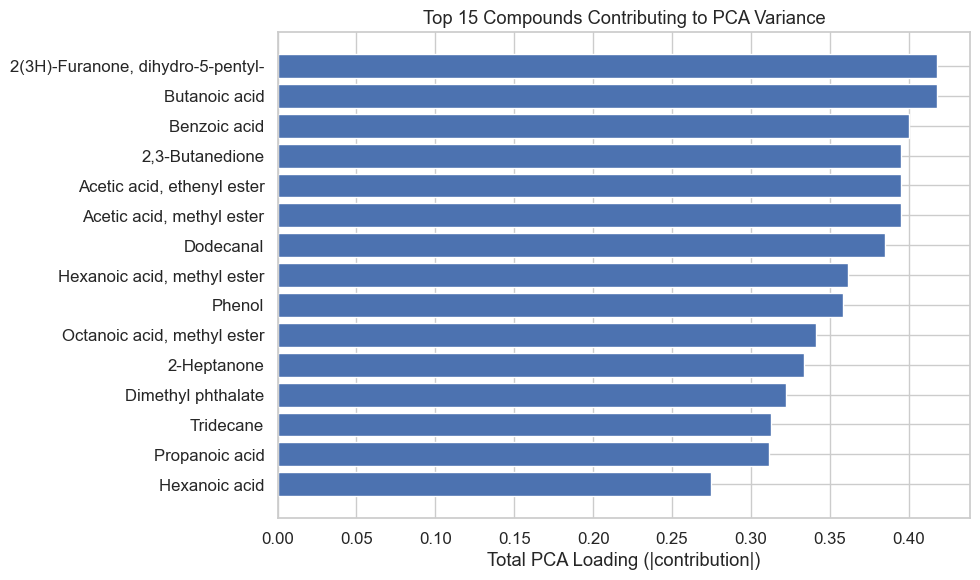

In [13]:

from compound_analysis_module import compute_feature_importance_from_pca
importance_df = compute_feature_importance_from_pca(aroma_matrix)


# Joining the sensory panel data 

In [15]:

#  Read sensory Excel file using correct config path
sensory_path = config["biorep1"]["data"]["sensory_data"]

# Load the sensory file
sensory = pd.read_excel(sensory_path)

print("Columns:", list(sensory.columns))
display(sensory.head(config["biorep1"]["settings"]["display_rows"]))


Columns: ['VARIETY', 'Variety_original', 'Unnamed: 2', 'Intensity of Skin Colour', 'Thickness of skin', 'Speckles/Blemishes', 'Wrinkles', 'Dryness', 'Skin Separation', 'Colour', 'Visible Ring', 'Patches/ Blemishes', 'Waxy/ Shine', 'Floury/Flaky', 'Intensity of Aroma', 'Earthy Aroma', 'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh', 'Intensity of Flavour', 'Potato Starch', 'Metallic Flavour', 'Bitter Flavour', 'Earthy Flavour', 'Sour Flavour', 'Fresh Flavour', 'Sweet Flavour', 'Root/ Vegetable Flavour', 'Farmyard (grass/hay) flavour', 'Acidic', 'Dry Mouthfeel', 'Waxy -Flesh', 'Mushy -Flesh', 'Crumbly - Flesh', 'Sticky - Flesh', 'Soft - Flesh', 'Chewy - Skin', 'Thickness - Skin', 'Starchy Aftertaste', 'Bitter Aftertaste', 'Drying Aftertaste', 'Sour Aftertaste', 'Sweet Aftertaste', 'Metalic', 'Unnamed: 47', 'cluster 1 Sp, cluster 3 UK', 'cluster 2 Sp, cluster 1 UK', 'cluster 3 Sp, cluster 2 UK', 'cluster 1 Sp, cluster 3 UK.1', 'cluster 2 Sp, cluster 1 UK.1', 'cluster 3 Sp, clus

,VARIETY,Variety_original,Unnamed: 2,Intensity of Skin Colour,Thickness of skin,Speckles/Blemishes,Wrinkles,Dryness,Skin Separation,Colour,...,Unnamed: 54,number ID,citric acid,Ras,Glucose mg/100 g FW,Fructose mg/100 g FW,Sucrose mg/100 g FW,Reducerende,% Reduc.,som
0,ADORA,ADORA,P1,47.229,23.958,44.438,12.667,40.521,20.188,20.708,...,NaN,1.0,88.2,Adora,249.3,175.5,46.5,424.8,90.133673,471.3
1,AGATA,AGATA,P2,30.604,18.896,41.417,13.125,33.5,25.229,37.167,...,NaN,2.0,89.7,Agata,437.0,296.8,158.6,733.8,82.227701,892.4
2,AGRIA,AGRIA,P3,61.187,33.875,32.333,10.229,50.979,29.708,64.583,...,NaN,3.0,37.8,Agria,19.3,7.0,51.3,26.3,33.891753,77.6
3,AMBRA,AMBRA,P4,43.667,21.354,28.458,10.333,36.729,20.479,53.417,...,NaN,4.0,38.2,Ambra,81.5,75.5,81.1,157.0,65.938681,238.1
4,AMPERA,AMPERA,P5,61.604,24.938,28.875,14.396,45.396,19.417,67.271,...,NaN,5.0,61.6,Ampera,178.1,130.6,105.6,308.7,74.511224,414.3


# Sensory Panel Data Processing

In [16]:

from compound_analysis_module import summarize_sensory_traits

# flavor-related columns
sensory_cols = [
    "Metallic Flavour","Bitter Flavour","Earthy Flavour","Sour Flavour",
    "Fresh Flavour","Sweet Flavour","Root/ Vegetable Flavour",
    "Farmyard (grass/hay) flavour","Bitter Aftertaste","Sour Aftertaste","Sweet Aftertaste", 'Earthy Aroma',
    'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh', 'Potato Starch','Metalic'
]

sensory_summary = summarize_sensory_traits(sensory, sensory_cols)

Rows (unique varieties): 59
Traits averaged: 20
  VARIETY  Metallic Flavour  Bitter Flavour  Earthy Flavour  Sour Flavour  \
0   ADORA            17.627          15.329          26.573        10.678   
1   AGATA            10.171          11.633          18.378         7.548   
2   AGRIA             8.018           5.872          20.421         3.787   
3   AMBRA            11.192          12.155          20.334         7.135   
4  AMPERA            13.018          11.176          20.486        11.591   

   Fresh Flavour  Sweet Flavour  Root/ Vegetable Flavour  \
0         24.014          3.098                   17.360   
1         30.340          3.250                   10.600   
2         29.188          1.859                   13.447   
3         33.122          2.729                   17.447   
4         24.644          3.511                   15.991   

   Farmyard (grass/hay) flavour  Bitter Aftertaste  ...  Sweet Aftertaste  \
0                        12.520             15.647 

In [17]:

from compound_analysis_module import summarize_sensory_traits

# flavor-related columns
sensory_cols = [
    "Metallic Flavour","Bitter Flavour","Earthy Flavour","Sour Flavour",
    "Fresh Flavour","Sweet Flavour","Root/ Vegetable Flavour",
    "Farmyard (grass/hay) flavour","Bitter Aftertaste","Sour Aftertaste","Sweet Aftertaste", 'Earthy Aroma',
    'Farmyard', 'Sweet', 'Starchy', 'Damp', 'Buttery', 'Fresh', 'Potato Starch','Metalic'
]

sensory_summary = summarize_sensory_traits(sensory, sensory_cols)

Rows (unique varieties): 59
Traits averaged: 20
  VARIETY  Metallic Flavour  Bitter Flavour  Earthy Flavour  Sour Flavour  \
0   ADORA            17.627          15.329          26.573        10.678   
1   AGATA            10.171          11.633          18.378         7.548   
2   AGRIA             8.018           5.872          20.421         3.787   
3   AMBRA            11.192          12.155          20.334         7.135   
4  AMPERA            13.018          11.176          20.486        11.591   

   Fresh Flavour  Sweet Flavour  Root/ Vegetable Flavour  \
0         24.014          3.098                   17.360   
1         30.340          3.250                   10.600   
2         29.188          1.859                   13.447   
3         33.122          2.729                   17.447   
4         24.644          3.511                   15.991   

   Farmyard (grass/hay) flavour  Bitter Aftertaste  ...  Sweet Aftertaste  \
0                        12.520             15.647 

# Merge aroma and sensory datasets

In [18]:

from compound_analysis_module import merge_aroma_with_sensory


merged_aroma_sensory= merge_aroma_with_sensory(aroma_matrix, sensory_summary)


Aroma varieties: 94
Sensory varieties: 59
Common: 20
Merged varieties: 20


# Correlation between aroma compounds and sensory attributes

In [19]:

# COPY (SAFETY)
aroma_df   = aroma_matrix.copy()
sensory_df = sensory_summary.copy()



#  Aroma 
if "Variety" in aroma_df.columns:
    aroma_df["VARIETY"] = (
        aroma_df["Variety"]
        .astype(str)
        .str.strip()
        .str.upper()
    )
else:
    raise KeyError("Aroma table must contain 'Variety' column")

#  Sensory 
if "VARIETY" in sensory_df.columns:
    sensory_df["VARIETY"] = (
        sensory_df["VARIETY"]
        .astype(str)
        .str.strip()
        .str.upper()
    )
elif "Variety" in sensory_df.columns:
    sensory_df["VARIETY"] = (
        sensory_df["Variety"]
        .astype(str)
        .str.strip()
        .str.upper()
    )
else:
    raise KeyError("Sensory table must contain VARIETY / Variety")


#  CHECK OVERLAP (DEBUG STEP)
common = sorted(
    set(aroma_df["VARIETY"]) &
    set(sensory_df["VARIETY"])
)

print("Aroma varieties:", aroma_df["VARIETY"].nunique())
print("Sensory varieties:", sensory_df["VARIETY"].nunique())
print("Common varieties:", len(common))
print("Example common:", common[:10])


# MERGE (INNER = ONLY COMMON)

merged_aroma_sensory = (
    aroma_df
    .merge(
        sensory_df,
        on="VARIETY",
        how="inner",
        validate="one_to_one"
    )
)

print("Merged rows:", merged_aroma_sensory.shape[0])

merged_aroma_sensory.head()


Aroma varieties: 94
Sensory varieties: 59
Common varieties: 20
Example common: ['ADORA', 'AGRIA', 'BERBER', 'BILDTSTAR', 'BINTJE', 'CARRERA', 'CECILE', 'CHALLENGER', 'DESIREE', 'FABULA']
Merged rows: 20


,Variety,(E)-2-Heptenal,1-Heptanol,"1-Hexanol, 2-ethyl-",1-Nonanol,1-Phenylethanol,"2(3H)-Furanone, dihydro-5-pentyl-","2,3-Butanedione","2,3-Pentanedione",2-Ethylfuran,...,Sweet Aftertaste,Earthy Aroma,Farmyard,Sweet,Starchy,Damp,Buttery,Fresh,Potato Starch,Metalic
0,ADORA,128937.591758,437142.618582,56064.041869,38119.222323,55570.692251,403890.359778,2.022206e+06,325499.702136,121322.202549,...,1.790,18.537,15.953,4.385,21.588,19.845,3.491,29.071,28.018,16.498
1,AGRIA,55666.690119,199337.469940,30443.492081,27321.683115,16118.227538,536271.530608,1.566615e+06,197136.144169,125679.229531,...,1.203,23.580,12.801,3.298,23.219,15.823,1.752,26.592,35.300,9.280
2,BERBER,36565.683618,245192.813005,35680.823419,16674.201405,34278.031857,634488.990975,1.445753e+06,185179.887278,83639.079072,...,3.355,16.732,10.866,7.146,24.719,12.410,4.535,31.505,34.713,7.520
3,BILDTSTAR,67923.300134,222870.367416,40320.853553,50399.166213,27103.911442,298994.677524,2.059754e+06,264326.371676,59592.812646,...,0.756,22.512,16.668,2.590,21.487,17.625,2.791,24.566,30.645,7.869
4,BINTJE,125523.226861,280639.916615,165688.018255,74555.636071,27345.419263,752566.088740,3.218577e+06,226064.408726,628160.693314,...,3.506,14.671,10.804,7.408,19.260,16.103,3.859,29.521,32.350,6.301


# Predicting Sensory Scores for Non-panel Varieties using KNN and PCA

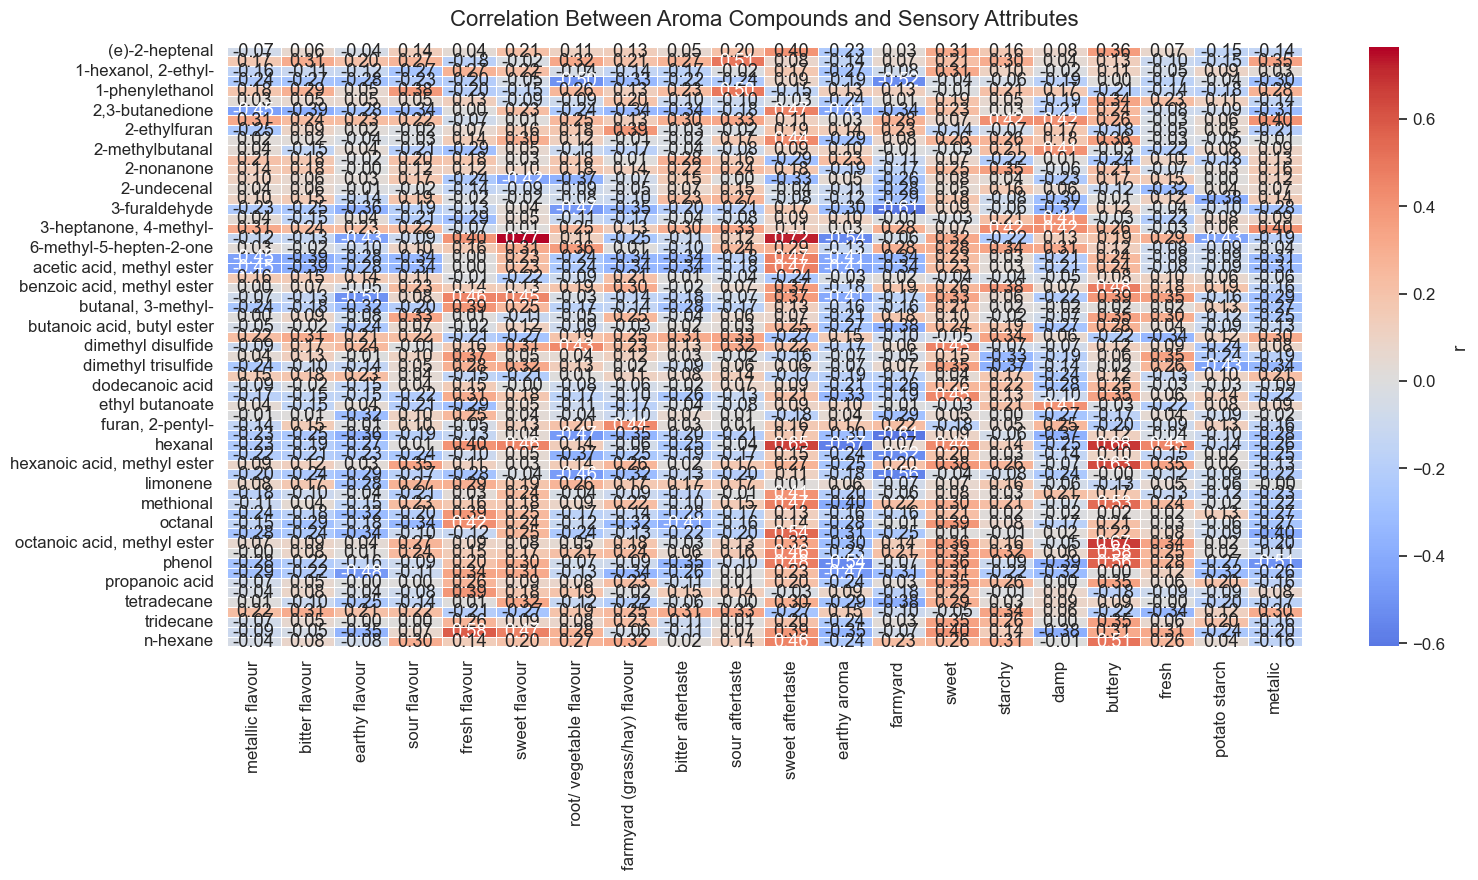

Saved: C:/Users/fatemehm/OneDrive - Royal HZPC Group/Documents/GitHub/internship/biorep2/aroma_sensory_corr_output.csv


In [20]:

from compound_analysis_module import plot_aroma_sensory_correlation

# Sensory columns
sensory_cols = [
    "Metallic Flavour","Bitter Flavour","Earthy Flavour","Sour Flavour",
    "Fresh Flavour","Sweet Flavour","Root/ Vegetable Flavour",
    "Farmyard (grass/hay) flavour","Bitter Aftertaste","Sour Aftertaste",
    "Sweet Aftertaste","Earthy Aroma","Farmyard","Sweet","Starchy",
    "Damp","Buttery","Fresh","Potato Starch","Metalic"
]

threshold = config["biorep2"]["settings"]["correlation_threshold"]
min_compounds = config["biorep2"]["settings"]["min_compounds"]

# FIXED: correct key
save_path = save_path = config["biorep2"]["data_paths"]["aroma_sensory_corr_output"]

corr_result = plot_aroma_sensory_correlation(
    merged_aroma_sensory=merged_aroma_sensory,
    sensory_cols=sensory_cols,
    aroma_descriptions={},   
    threshold=threshold,
    min_compounds=min_compounds,
    save_path=save_path
)



# Predicting Sensory Scores for Non-panel Varieties using KNN and PCA

In [21]:
from compound_analysis_module import perform_knn_sensory_projection

# Paths from config
projection_path = config["biorep2"]["data_paths"]["aroma_sensory_corr_output"].replace(
    "aroma_sensory_corr_output.csv",
    "sensory_pca_projection_knn.csv"
)

loadings_path = projection_path.replace(
    "sensory_pca_projection_knn.csv",
    "sensory_pca_loadings.csv"
)

pc_df_path = projection_path.replace(
    "sensory_pca_projection_knn.csv",
    "sensory_pca_pc_df.csv"
)


# FIX aroma_long → aroma_wide 
aroma_long_fixed = aroma_long.copy()

if "VARIETY" not in aroma_long_fixed.columns and "Variety" in aroma_long_fixed.columns:
    aroma_long_fixed = aroma_long_fixed.rename(columns={"Variety": "VARIETY"})

aroma_long_fixed["VARIETY"] = (
    aroma_long_fixed["VARIETY"]
    .astype(str)
    .str.strip()
    .str.upper()
)

aroma_wide = (
    aroma_long_fixed
    .pivot_table(
        index="VARIETY",
        columns="Compound Name",
        values="Intensity",
        aggfunc="mean"
    )
    .reset_index()
)

# numeric safety
compound_cols = [c for c in aroma_wide.columns if c != "VARIETY"]
aroma_wide[compound_cols] = aroma_wide[compound_cols].apply(
    pd.to_numeric, errors="coerce"
).fillna(0)


pc_df, pca, loadings_df = perform_knn_sensory_projection(
    aroma_matrix=aroma_wide,
    sensory_summary=sensory_summary,
    k=3,
    n_components=3,
    scaling_factor=15,
    save_projection_path=projection_path,
    save_loadings_path=loadings_path
)

Panel varieties: 20
Aroma non-panel varieties: 74
Explained variance ratio: [0.449 0.194 0.089]
Total projected varieties: 94


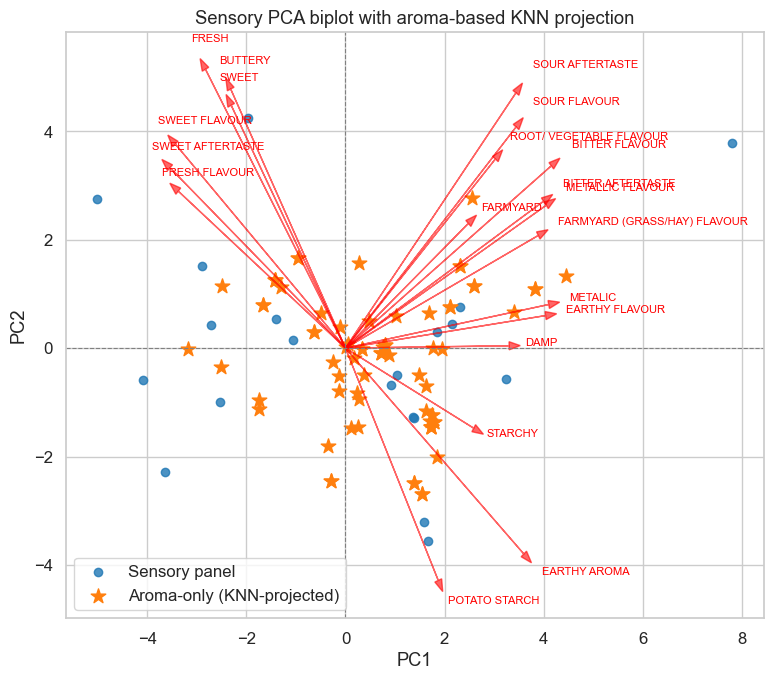

In [22]:
from compound_analysis_module import plot_sensory_pca_biplot

plot_sensory_pca_biplot(pc_df, loadings_df, scaling_factor=15)
